In [28]:
import pydeltasnow as pyds

import os
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"
os.chdir(base_dir)

import HNW_validation.HNW_validation_helper as val_helper

In [29]:
infile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_input_Mag25/Mag25_all.nc" # always the same 



csv_file = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_SWE_mod_from_R_dyn_rho_max.csv"
outfile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final_R_dyn_rho_max.nc"

# load original dataset
ds = xr.open_dataset(infile)

# read CSV from R
SWE_mod = pd.read_csv(csv_file).to_numpy()

# R matrix is station x time -> xarray needs time x station
SWE_mod = SWE_mod.T

# safety check
assert SWE_mod.shape == (ds.sizes["time"], ds.sizes["station"])

# add variable
ds["SWE_mod"] = xr.DataArray(
    SWE_mod,
    coords={"time": ds["time"], "station": ds["station"]},
    dims=("time", "station"),
)

ds.to_netcdf(outfile)

# Load dataset
Mag25_data = ds


# Run with pydeltasnow (caution optional)

In [30]:
# # Load dataset
# Mag25_data = xr.open_dataset(infile)

# # Create copy of original dataset
# Mag25_data_with_SWE = Mag25_data.copy()

# # Add empty SWE_mod variable for all stations
# Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

# # Store number of observed SWE measurements per station
# obs_counts = []

# # Get all station names
# station_list = Mag25_data["station"].values

# for station_name in station_list:
#     print(f"\nProcessing station: {station_name}")

#     # Select one station and convert to pandas Series
#     idata = Mag25_data["HS"].transpose("time", "station").sel(station=station_name).to_pandas()

#     print(f"HS input shape: {idata.shape}")

#     # Run DeltaSNOW model
#     swe_results = pyds.swe_deltasnow(
#         idata,
#         hs_input_unit="m",
#         swe_output_unit="mm",
#         output_series_name="SWE_mod"
#     )

#     # Check shape
#     assert swe_results.shape[0] == Mag25_data.sizes["time"]

#     # Insert modeled values for this station
#     Mag25_data_with_SWE["SWE_mod"].loc[dict(station=station_name)] = swe_results.values

#     # Count available observed SWE measurements
#     swe_obs = Mag25_data_with_SWE["SWE"].sel(station=station_name)
#     n_obs = swe_obs.notnull().sum().item()
#     print(f"Number of SWE observations: {n_obs}")

#     obs_counts.append({
#         "station": station_name,
#         "n_obs": n_obs
#     })


# # Create summary table
# obs_counts_df = pd.DataFrame(obs_counts)
# print(obs_counts_df)

# Creat HNW_mod Data

In [31]:
Mag25_data_with_SWE = Mag25_data.copy()

# Calculate day-to-day SWE increase
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time")

# Clip negative values to 0
HNW_mod = HNW_mod.clip(min=0)

# Reindex back to the original time axis
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

# Add to dataset
Mag25_data_with_SWE["HNW_mod"] = HNW_mod

{'RMSE': 3.0243677227133654, 'Bias': -0.32669343263095113, 'Rel_BIAS': -0.154287051041374, 'R2': 0.825922478397808, 'N': 36487}
Plot saved to: HNW_validation/dSnow/validation_plots/deltasnow_hnw_validation_R_dyn_rho_max.png


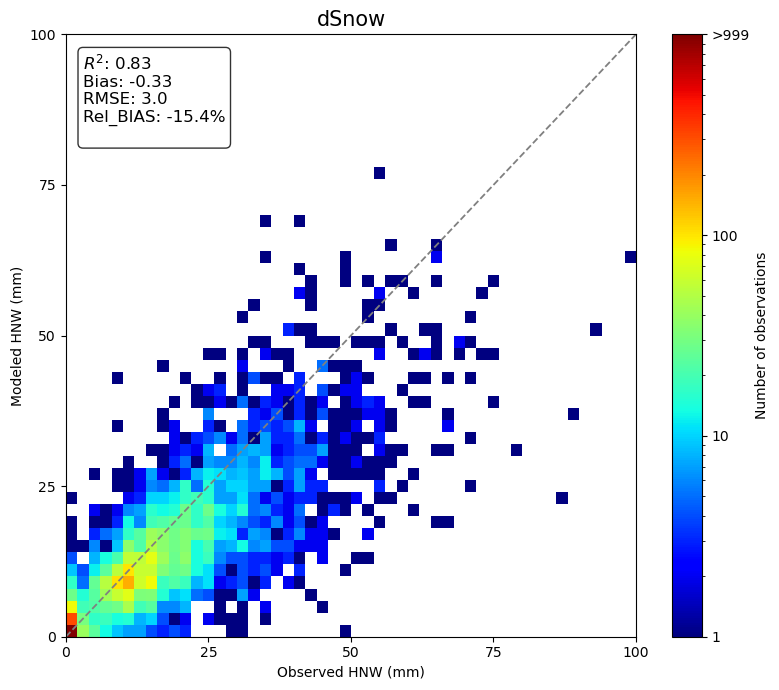

{'RMSE': 3.0243677227133654,
 'Bias': -0.32669343263095113,
 'Rel_BIAS': -0.154287051041374,
 'R2': 0.825922478397808,
 'N': 36487}

In [32]:
all_df = Mag25_data_with_SWE[["HNW", "HNW_mod"]].to_dataframe().reset_index()
all_df = all_df.rename(columns={
    "HNW": "HNW_obs",
    "HNW_mod": "HNW_mod"
})

all_df.index = all_df.index.astype("datetime64[ns]")

val_helper.validate_hnw_mag25(all_df,
                            model_name= 'dSnow', 
                            obs_col= "HNW_obs", 
                            mod_col= "HNW_mod",
                            save_dir="HNW_validation/dSnow/validation_plots",
                            filename="deltasnow_hnw_validation_R_dyn_rho_max.png")

In [33]:
# Save output dataset
#
#Mag25_data_with_SWE.to_netcdf("HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final.nc")
#Mag25_data_with_SWE  = xr.open_dataset('HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final.nc')

# Validate SWE

Number of valid observations after filtering: 1102
{'RMSE': 38.14739865141687, 'Bias': 4.013939987748947, 'Rel_BIAS': 0.017919077319979618, 'R2': 0.9439401028234254, 'N': 1102}
Plot saved to: HNW_validation/dSnow/validation_plots/deltasnow_SWE_validation_R_dyn_rho_max.png


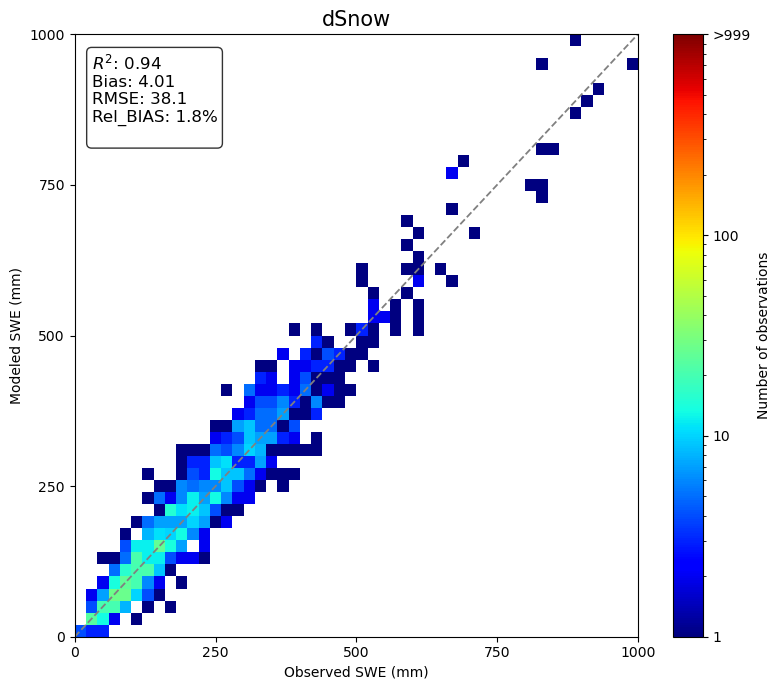

{'RMSE': 38.14739865141687,
 'Bias': 4.013939987748947,
 'Rel_BIAS': 0.017919077319979618,
 'R2': 0.9439401028234254,
 'N': 1102}

In [34]:
all_df_SWE = Mag25_data_with_SWE[["SWE", "SWE_mod"]].to_dataframe().reset_index()
all_df_SWE = all_df_SWE.rename(columns={
    "SWE": "SWE_obs",
    "SWE_mod": "SWE_mod"
})

all_df_SWE.index = all_df_SWE.index.astype("datetime64[ns]")

val_helper.validate_swe_mag25(all_df_SWE, 
                              model_name="dSnow",
                              save_dir="HNW_validation/dSnow/validation_plots",
                              filename="deltasnow_SWE_validation_R_dyn_rho_max.png")